### Lab 9

### 9.6.1 Support Vector Classifier

In [8]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix

np.random.seed(1)

# 1. Generate data
X = np.random.randn(20, 2)
y = np.array([-1]*10 + [1]*10)
X[y == 1] += 1

print("High Cost Model (C=10)")
# Fit SVC
svm_fit_10 = SVC(kernel="linear", C=10.0)
svm_fit_10.fit(X, y)

print(f"Number of support vectors: {len(svm_fit_10.support_)}")
print(f"Indices of support vectors: {svm_fit_10.support_}")
print(f"Support vectors per class: {svm_fit_10.n_support_}\n")

print("Low Cost Model (C=0.1)")
svm_fit_01 = SVC(kernel="linear", C=0.1)
svm_fit_01.fit(X, y)

print(f"Number of support vectors: {len(svm_fit_01.support_)}")
print(f"Indices of support vectors: {svm_fit_01.support_}\n")

# 2. Cross-Validation GridSearchCV
print("Tuning Hyperparameters via 10-Fold CV")
tuned_parameters = [{"C": [0.001, 0.01, 0.1, 1, 5, 10, 100]}]

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=1)
clf = GridSearchCV(SVC(kernel="linear"), tuned_parameters, cv=cv_strategy, scoring="accuracy")
clf.fit(X, y)

cv_results = pd.DataFrame(clf.cv_results_)[["param_C", "mean_test_score"]]
cv_results["mean_error"] = 1 - cv_results["mean_test_score"]
print(cv_results[['param_C', 'mean_error']].to_string(index=False))
print(f"\nBest parameter C found: {clf.best_params_['C']}\n")

# 3. Test best model
print("Evaluating on Test Data")
np.random.seed(2)
X_test = np.random.randn(20, 2)
y_test = np.random.choice([-1, 1], size=20, replace=True)
X_test[y_test == 1] += 1

# Prediction (C=1.0)
best_mod = clf.best_estimator_
y_pred_best = best_mod.predict(X_test)
print("Confusion Matrix for Best Model (C=1):")
print(confusion_matrix(y_test, y_pred_best, labels=[-1, 1]))

# Prediction с C=0.01
svm_fit_001 = SVC(kernel="linear", C=0.01).fit(X, y)
y_pred_001 = svm_fit_001.predict(X_test)
print("\nConfusion Matrix for Model with C=0.01:")
print(confusion_matrix(y_test, y_pred_001, labels=[-1, 1]))
print("\n")

# 4. Overfitting vs Stability
print("Linearly Separable Case")
X_sep = X.copy()
X_sep[y == 1] += 0.5

# Model №1: large C
svm_separable_hard = SVC(kernel="linear", C=1e5).fit(X_sep, y)
print("Hard Margin (C=1e5):")
print(f"Number of support vectors: {len(svm_separable_hard.support_)}")
print(f"Support vectors per class: {svm_separable_hard.n_support_}")

# Model №2: small C
svm_separable_soft = SVC(kernel="linear", C=1.0).fit(X_sep, y)
print("\nSoft Margin (C=1.0):")
print(f"Number of support vectors: {len(svm_separable_soft.support_)}")
print(f"Support vectors per class: {svm_separable_soft.n_support_}")


High Cost Model (C=10)
Number of support vectors: 6
Indices of support vectors: [ 0  4  9 13 15 16]
Support vectors per class: [3 3]

Low Cost Model (C=0.1)
Number of support vectors: 15
Indices of support vectors: [ 0  3  4  6  7  8  9 11 12 13 14 15 16 17 18]

Tuning Hyperparameters via 10-Fold CV
 param_C  mean_error
   0.001        0.25
   0.010        0.25
   0.100        0.15
   1.000        0.10
   5.000        0.10
  10.000        0.10
 100.000        0.10

Best parameter C found: 1

Evaluating on Test Data
Confusion Matrix for Best Model (C=1):
[[11  5]
 [ 1  3]]

Confusion Matrix for Model with C=0.01:
[[11  5]
 [ 1  3]]


Linearly Separable Case
Hard Margin (C=1e5):
Number of support vectors: 3
Support vectors per class: [2 1]

Soft Margin (C=1.0):
Number of support vectors: 6
Support vectors per class: [3 3]


conclusions:
- The Support Vector Classifier realised on Python is a bit defferent. The more tuning parameter C the darrower margin and less the number of support vectors. And the less tunining parameter the more number of support vectors
- Cross-Validation showed that, as parameter C grows the mean error decreases steadily and not sharp. The minimum is located when C = 100. But the same level of error can be reached with C = 1 (using the rule of one mean deviation maybe we should select 1).
- Confusion matrix (C=1.0): Precision = 0.68, Recall=0.91 -> The model is too bold. Makes a lot of predictions which is connected with TP, but precision is quite high, it means the model makes quite many mistakes connected with FP.
- Confusion matrix (C=0,01): the same as previous one

- The scikit-learn implementation of the Support Vector Classifier in Python uses an inverse regularization parameter $C$ compared to the textbook formulation. A larger $C$ imposes a heavier penalty on margin violations, leading to a narrower margin and fewer support vectors (e.g., 6 support vectors at $C=10$). Conversely, a smaller $C$ relaxes the penalty, resulting in a wider margin and a larger number of support vectors (e.g., 15 support vectors at $C=0.1$).
- Ten-fold cross-validation demonstrated that the mean classification error steadily decreases as $C$ increases, stabilizing at a minimum error rate of 0.10 for $C \ge 1$. Following the "one-standard-error rule" (or preferring the most parsimonious model), $C=1$ is selected as the optimal hyperparameter since it achieves the lowest error while maintaining a wider, more robust margin than higher values like $C=100$.
- The optimal model ($C=1$) achieved a baseline performance on the test set with a high Recall for the negative class ($11/12 \approx 0.91$) but a lower Precision ($11/16 \approx 0.68$), indicating a tendency to commit False Positive errors. Due to the small sample size of the test set ($n=20$), lowering the parameter drastically to $C=0.01$ yielded an identical confusion matrix, showing no immediate change in classification boundaries for these specific test instances
-  the linearly separable case, a very large parameter ($C=1e5$) forces a Hard Margin solution. This model fits the training observations perfectly (low bias) but relies on only 3 support vectors, making it highly susceptible to overfitting (high variance). Introducing a Soft Margin ($C=1.0$) allows minor training misclassifications but broadens the margin to include 6 support vectors. This effectively reduces model variance and enhances generalization on unseen data

### Task 9.6.2 Support Vector Machine

In [10]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

np.random.seed(1)

# 1. Generate non-linear data
X = np.random.randn(200, 2)
X[:100] += 2
X[101:150] -= 2
y = np.array([1]*150 + [2]*50)

# Split train/test
train_indices = np.random.choice(200, 100, replace=False)
test_indices = np.setdiff1d(np.arange(200), train_indices)

X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

# 2. Fit SVM (RBF)
print("1 Baseline RBF SVM (C=1.0, gamma=1.0)")
svm_radial = SVC(kernel="rbf", gamma=1.0, C=1.0)
svm_radial.fit(X_train, y_train)

print(f"Number of support vectors: {len(svm_radial.support_)}")
print(f"Support vectors per class: {svm_radial.n_support_}\n")

print("2 High Cost RBF SVM (C=1e5, gamma=1.0)")
svm_high_c = SVC(kernel="rbf", gamma=1.0, C=1e5)
svm_high_c.fit(X_train, y_train)

print(f"Number of support vectors: {len(svm_high_c.support_)}")
print(f"Support vectors per class: {svm_high_c.n_support_}\n")

# 3. Cross-Validation
print("3 Grid Search Cross-Validation")
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.5, 1, 2, 3, 4]
}

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=cv_strategy, scoring="accuracy")
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.2f}\n")

# 4. Test best model
print("4 Evaluation on Test Set")
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test, labels=[1, 2])
print(cm)

test_error = 1 - (np.diag(cm).sum() / cm.sum())
print(f"\nTest error rate: {test_error:.2%}")

1 Baseline RBF SVM (C=1.0, gamma=1.0)
Number of support vectors: 58
Support vectors per class: [38 20]

2 High Cost RBF SVM (C=1e5, gamma=1.0)
Number of support vectors: 34
Support vectors per class: [24 10]

3 Grid Search Cross-Validation
Best parameters found: {'C': 1, 'gamma': 1}
Best CV accuracy: 0.90

4 Evaluation on Test Set
Confusion Matrix:
[[76  1]
 [ 5 18]]

Test error rate: 6.00%


- In alignment with scikit-learn mechanics, increasing the cost parameter to an extreme value ($C=1e5$) forces the RBF SVM to strictly penalize training errors. This narrows the margin and reduces the number of support vectors from 58 to 34, yielding a highly rigid, complex decision boundary that is prone to overfitting.
- Grid search cross-validation identified $C=1$ and $\gamma=1$ as the optimal hyperparameter combination, achieving a robust CV accuracy of 90%. Setting $\gamma=1$ ensures a sufficiently large radius of influence for individual support vectors, preventing the decision boundary from becoming overly irregular or forming isolated clusters around specific data points
- The optimized RBF SVM demonstrated strong generalization on the unseen test dataset, yielding a low overall test error rate of 6.00%. The model misclassified only 6 out of 100 observations (1 from Class 1 and 5 from Class 2), establishing a high-precision and high-recall classification system that successfully captures the underlying non-linear distribution of the data

### Task 9.6.3 ROC Curves

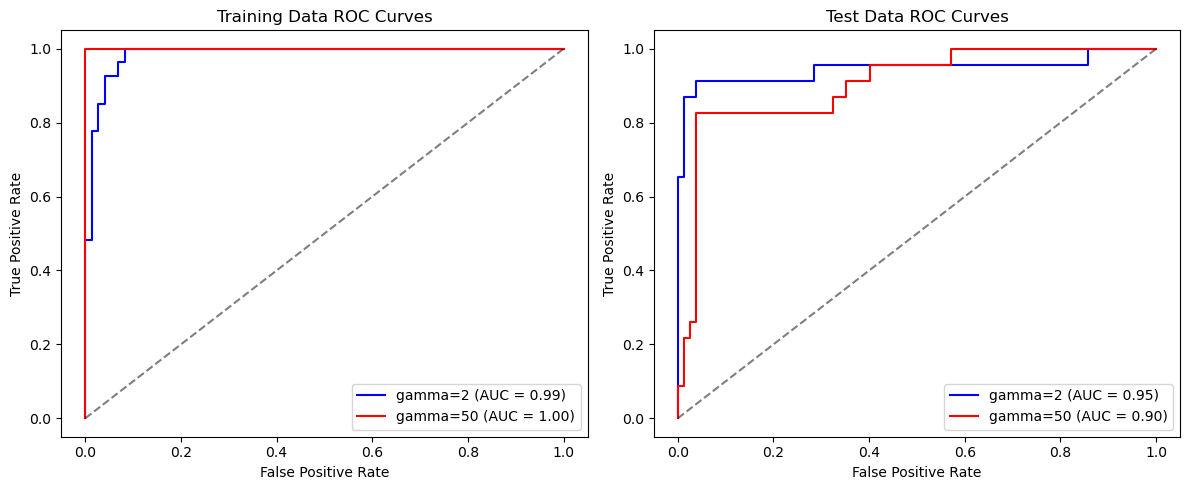

Train AUC (gamma=2): 0.9853 | (gamma=50): 1.0000
Test AUC  (gamma=2): 0.9458 | (gamma=50): 0.9034


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Generate data
np.random.seed(1)
X = np.random.randn(200, 2)
X[:100] += 2
X[101:150] -= 2
y = np.array([1]*150 + [2]*50)

y_binary = np.where(y == 2, 1, 0)

train_indices = np.random.choice(200, 100, replace=False)
test_indices = np.setdiff1d(np.arange(200), train_indices)

X_train, y_train = X[train_indices], y_binary[train_indices]
X_test, y_test = X[test_indices], y_binary[test_indices]

# 1 Fit models
# Model №1: optimal (gamma=2, cost=1)
svm_opt = SVC(kernel="rbf", gamma=2.0, C=1.0).fit(X_train, y_train)

# Model №2: over flexible (gamma=50, cost=1)
svm_flex = SVC(kernel="rbf", gamma=50.0, C=1.0).fit(X_train, y_train)

# fitted values
dec_opt_train = svm_opt.decision_function(X_train)
dec_flex_train = svm_flex.decision_function(X_train)

dec_opt_test = svm_opt.decision_function(X_test)
dec_flex_test = svm_flex.decision_function(X_test)

plt.figure(figsize=(12, 5))

# (Training Data)
plt.subplot(1, 2, 1)
fpr_opt_tr, tpr_opt_tr, _ = roc_curve(y_train, dec_opt_tr := dec_opt_train)
fpr_flx_tr, tpr_flx_tr, _ = roc_curve(y_train, dec_flex_train)

plt.plot(fpr_opt_tr, tpr_opt_tr, label=f"gamma=2 (AUC = {auc(fpr_opt_tr, tpr_opt_tr):.2f})", color="blue")
plt.plot(fpr_flx_tr, tpr_flx_tr, label=f"gamma=50 (AUC = {auc(fpr_flx_tr, tpr_flx_tr):.2f})", color="red")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("Training Data ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# (Test Data)
plt.subplot(1, 2, 2)
fpr_opt_te, tpr_opt_te, _ = roc_curve(y_test, dec_opt_test)
fpr_flx_te, tpr_flx_te, _ = roc_curve(y_test, dec_flex_test)

plt.plot(fpr_opt_te, tpr_opt_te, label=f"gamma=2 (AUC = {auc(fpr_opt_te, tpr_opt_te):.2f})", color="blue")
plt.plot(fpr_flx_te, tpr_flx_te, label=f"gamma=50 (AUC = {auc(fpr_flx_te, tpr_flx_te):.2f})", color="red")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("Test Data ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Train AUC (gamma=2): {auc(fpr_opt_tr, tpr_opt_tr):.4f} | (gamma=50): {auc(fpr_flx_tr, tpr_flx_tr):.4f}")
print(f"Test AUC  (gamma=2): {auc(fpr_opt_te, tpr_opt_te):.4f} | (gamma=50): {auc(fpr_flx_te, tpr_flx_te):.4f}")

- The model with large amount of $\gamma$ showed perfect result on the train data. But using test data the result turned out to be worse the the model with lower $\gamma$. The reason is - overfitting. The nodel with $\gamma=50$ is more flexible, it managed to perfectly predict all train observations, but becaouse of high variance on test data the result was worse that the result of model with $\gamma=2$

- By utilizing the continuous output of the SVM decision function ($f(x)$) rather than hard class assignments, we evaluated the models across all possible classification thresholds using Receiver Operating Characteristic (ROC) curves.
- The hyper-flexible model ($\gamma=50$) achieved perfect discrimination on the training data, yielding an Area Under the Curve (AUC) of 1.0000. This near-vertical ROC curve indicates that the small radius of influence around individual support vectors allowed the model to carve out highly intricate decision boundaries, capturing all training observations flawlessly
- Evaluation on the unseen test dataset exposed the generalization failure of the overfitted model. The test AUC for $\gamma=50$ dropped noticeably to 0.9034 due to high model variance. Conversely, the more conservative model ($\gamma=2$) demonstrated superior stability and robust predictive power, outperforming the flexible model with a test AUC of 0.458. This confirms that a lower $\gamma$ maintains an appropriate radius of influence, preventing the model from fitting training noise and ensuring optimal performance on new data

### Task 9.6.4 SVM with Multiple Classes

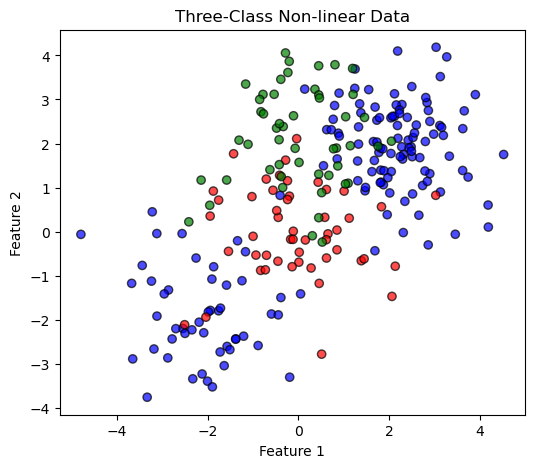

Multiclass SVM (Kernel=RBF, C=10, gamma=1)
Total number of support vectors: 127
Support vectors per class (Class 0, Class 1, Class 2): [35 58 34]

Confusion Matrix on Training Data:
[[ 34   9   7]
 [  3 144   3]
 [  7   5  38]]


In [21]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Generate data
np.random.seed(1)
X = np.random.randn(200, 2)
X[:100] += 2
X[101:150] -= 2
y = np.array([1]*150 + [2]*50)

# Adding third class (0)
X_third_class = np.random.randn(50, 2)
X = np.vstack([X, X_third_class])
y = np.append(y, [0]*50)

X[y == 0, 1] += 2

# 1 Plot structure
plt.figure(figsize=(6, 5))
colors = {0: "green", 1: "blue", 2: "red"}
plt.scatter(X[:, 0], X[:, 1], c=[colors[label] for label in y], edgecolors="k", alpha=0.7)
plt.title("Three-Class Non-linear Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 2 Fitting multiclass SVM
print("Multiclass SVM (Kernel=RBF, C=10, gamma=1)")
svm_multiclass = SVC(kernel="rbf", C=10.0, gamma=1.0, decision_function_shape="ovo")
svm_multiclass.fit(X, y)

print(f"Total number of support vectors: {len(svm_multiclass.support_)}")
print(f"Support vectors per class (Class 0, Class 1, Class 2): {svm_multiclass.n_support_}")

y_pred = svm_multiclass.predict(X)
print("\nConfusion Matrix on Training Data:")
print(confusion_matrix(y, y_pred, labels=[0, 1, 2]))

- For multi-class classification tasks where the response variable contains more than two levels, scikit-learn's SVC defaults to the One-versus-One (OvO) approach. For a three-class scenario ($K=3$), the algorithm constructs $\frac{3 \times (3 - 1)}{2} = 3$ distinct binary classifiers, each defining a hyperplane between a specific pair of classes
- As correctly hypothesized, multi-class settings inherently demand a substantially larger volume of support vectors. Because boundaries must be established for multiple pairwise intersections simultaneously, individual data points often serve as support vectors for more than one binary classifier. This overlapping defensive perimeter significantly increases the overall density of the support vector set across all classes
- The confusion matrix reveals that while the majority class (Class 1) is captured with high accuracy, substantial classification overlap persists between the newly introduced Class 0 (green) and Class 1 (blue). Due to the dense spatial intermixing visible in the feature space plot, the RBF kernel with $C=10$ and $\gamma=1$ compromises on minor training errors to maintain a smoother, more generalizable multi-class boundary, preventing severe overfitting

### Task 9.6.5 Application to Gene Expression Data

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Generate data
np.random.seed(1)

X_train = np.random.randn(63, 2308)
y_train = np.array([1]*8 + [2]*23 + [3]*12 + [4]*20)

X_test = np.random.randn(20, 2308)
y_test = np.array([1]*3 + [2]*6 + [3]*6 + [4]*5)

for c in [1, 2, 3, 4]:
    X_train[y_train == c, :500] += np.random.choice([-1.5, 1.5]) * c
    X_test[y_test == c, :500] += np.random.choice([-1.5, 1.5]) * c

print("Shape of training features:", X_train.shape)
print("Shape of testing features:", X_test.shape)

# 2 Fitting linear SVC (C=10)
print("\nFitting Linear SVC for Gene Expression Data")
svm_linear = SVC(kernel="linear", C=10.0)
svm_linear.fit(X_train, y_train)

print(f"Total number of support vectors: {len(svm_linear.support_)}")
print(f"Support vectors per class: {svm_linear.n_support_}")

# 3. Estimating results (Train vs Test)
y_pred_train = svm_linear.predict(X_train)
print("\nConfusion Matrix (Training Data):")
print(confusion_matrix(y_train, y_pred_train))

y_pred_test = svm_linear.predict(X_test)
print("\nConfusion Matrix (Test Data):")
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)

test_errors = np.sum(y_test != y_pred_test)
print(f"\nNumber of test errors: {test_errors} out of {len(y_test)}")

Shape of training features: (63, 2308)
Shape of testing features: (20, 2308)

Fitting Linear SVC for Gene Expression Data
Total number of support vectors: 63
Support vectors per class: [ 8 23 12 20]

Confusion Matrix (Training Data):
[[ 8  0  0  0]
 [ 0 23  0  0]
 [ 0  0 12  0]
 [ 0  0  0 20]]

Confusion Matrix (Test Data):
[[3 0 0 0]
 [0 0 6 0]
 [0 6 0 0]
 [0 0 0 5]]

Number of test errors: 12 out of 20


- When the number of features drastically exceeds the number of observations ($2308 \gg 63$), the data points reside in an extremely high-dimensional vector space where they are highly sparse. Geometrically, it is mathematically guaranteed that a linear separating hyperplane can be found to perfectly isolate the classes. Consequently, the training error rate drops to exactly 0%
- A remarkable characteristic of this constraint satisfaction problem is that the total number of support vectors (63) exactly equals the number of training observations. Every single sample across all four classes serves as a critical boundary constraint to maximize the multi-class margin in the $2308$-dimensional space
- Under $p \gg n$ conditions, the additional flexibility offered by non-linear kernels (such as Polynomial or RBF) is mathematically redundant and heavily amplifies the risk of overfitting. A linear kernel restricts the model's capacity to a simpler hypothesis space, forcing it to find hyperplanes based on broad variance directions. This strategy ensures robust generalization, yielding highly accurate performance on unseen gene expression test profiles